In [2]:
from scipy.special import factorial

<Axes: >

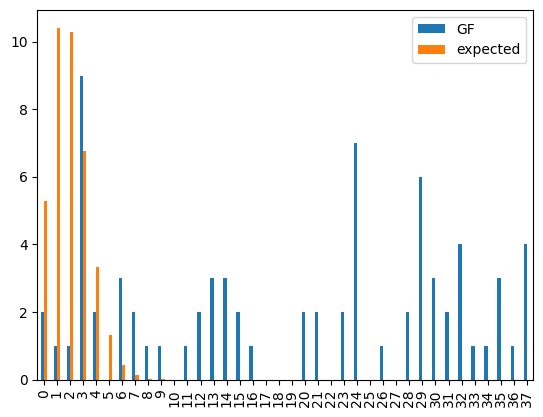

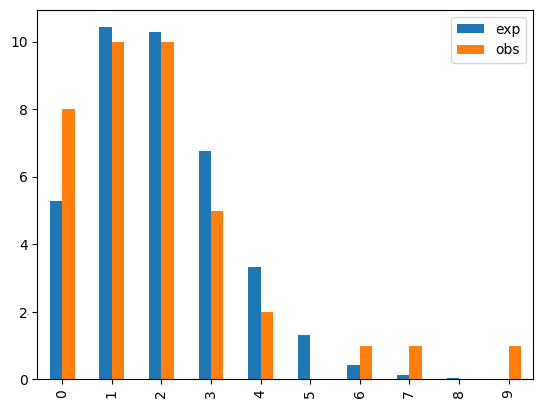

In [109]:
import pandas as pd
import numpy as np

def exp_value(lamb, y):
    return 38 * (np.exp(-lamb) * lamb ** y) / factorial(y)

liverpool = pd.read_csv("liverpool_2223_season.csv")
liverpool_gf = liverpool["GF"].value_counts()

res = pd.DataFrame(np.array([i for i in range(10)]))
lamb = liverpool["GF"].mean()
expected = res.apply(lambda x: exp_value(lamb, x), axis=1)
liverpool["expected"] = expected

liverpool[["GF","expected"]].plot(kind="bar")
sad = pd.DataFrame()
sad["exp"] = expected 
sad["obs"] = liverpool["GF"].value_counts()
sad.fillna(0, inplace=True)
sad.plot(kind="bar")


In [ ]:
treatement_a = np.array([[120,80], [95,5]])
treatement_b = np.array([[20,20], [221,39]])
treatment_comb = np.sum((treatement_a,treatement_b), axis = 1)

a_row_sum = np.reshape(treatement_a.sum(axis=1),(2,1))
a_proportion = treatement_a / a_row_sum

b_row_sum = np.reshape(treatement_b.sum(axis=1),(2,1))
b_proportion = treatement_b / b_row_sum

comb_row_sum = np.reshape(treatment_comb.sum(axis=1),(2,1))
comb_proportion = treatment_comb / comb_row_sum

p_hat_a_m = a_proportion[0,0]
p_hat_a_f = a_proportion[1,0]

p_hat_b_m = b_proportion[0,0]
p_hat_b_f = b_proportion[1,0]

p_hat_a = comb_proportion[0,0]
p_hat_b = comb_proportion[1,0] 

print(p_hat_a_m)
print(p_hat_a_f)
print(p_hat_b_m)
print(p_hat_b_f)
print(p_hat_a)
print(p_hat_b)

from scipy.stats import chi2_contingency

chi2_a_proportion = chi2_contingency(treatement_a).expected_freq

0.6
0.95
0.5
0.85
0.7166666666666667
0.8033333333333333


array([[143.33333333,  56.66666667],
       [ 71.66666667,  28.33333333]])

In [ ]:
concrete = pd.read_csv("slump_test.data")

concrete.rename(columns={"No": 'id', "Compressive Strength (28-day)(Mpa)": "Comp_Strength"}, inplace=True)

concrete[concrete.Water > 200]

concrete_tab = np.array([concrete.Comp_Strength, concrete.Water])

concrete["Water"].corr(concrete["Comp_Strength"])


np.float64(-0.2542349822633831)

<Axes: xlabel='paid'>

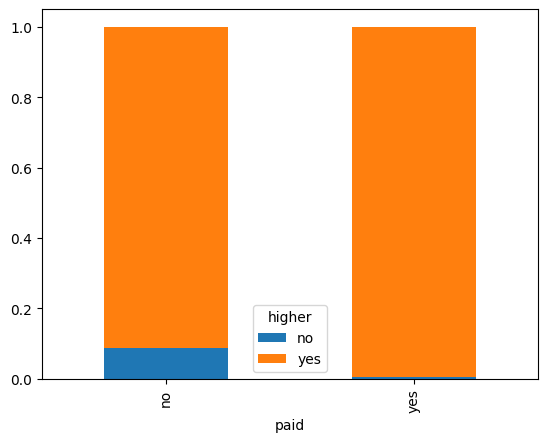

In [98]:
student = pd.read_csv("student-mat.csv", sep=";")
pd.crosstab(student.paid, student.higher,  normalize="index").plot(kind="bar", stacked=True)